In [1]:
import datetime
import sys, os, logging
from pathlib import Path

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
%matplotlib inline 


logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import (
    list_h5_parts, load_model, load_mc_test_parts,
    load_exp_parts, load_mc_reco_parts, predict_scores,
    plot_event_3d, load_blind_reco,
    EXP_RECO_COL_NAMES, MC_RECO_COL_NAMES, COMMON_RECO_COLS,
)

%load_ext autoreload
%autoreload 2

In [2]:
DA_MODEL_NAME = "../test_exp_reco_mc_reco/da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss"
NODA_MODEL_NAME = "../test_exp_reco_mc_reco/da_prefilter_numu_260428_2039_Qclip_softlabels_PlateauLR_lambda0.0_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss"
DA_SAVE_DIR = Path(f"./{DA_MODEL_NAME}")
NODA_SAVE_DIR = Path(f"./{NODA_MODEL_NAME}")

# ── Figures output directory ──
FIGURES_DIR = Path('.')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str, rewrite=True) -> None:
    """Save figure to FIGURES_DIR; raise FileExistsError if already present."""
    fig_path = FIGURES_DIR / filename
    if not rewrite and fig_path.exists():
        raise FileExistsError(f"Figure already exists: {fig_path}")
    fig.savefig(fig_path, dpi=170, bbox_inches="tight")
    print(f"Saved: {fig_path}")

def get_mask(df, theta_cuts=(0, 30)):
    theta_mask = (df['thetaRec'] > theta_cuts[0]) & (df['thetaRec'] <= theta_cuts[1]) & (df['scfMaxTheta'] < (theta_cuts[1]*1.2)/180*3.1428)
    theta_mask_conj = ~theta_mask
    mask = np.ones(len(df), dtype=bool)
    mask = mask & (df['nHits'] >= 8)
    mask = mask & (df['nStrings'] >= 3)
    mask = mask & (df['covMatrixStatus'] == 3)
    mask = mask & (np.log10(df['pHit']) > -9.)
    mask = mask & (df['evCenterZ'] < 220)
    mask = mask & (df['zDist'] > 70)
    mask = mask & (df['pathLength'] > 50)
    mask = mask & (np.log10(df['funcValue'] / (df['nHits'] - 5)) < 2.)
    mask = mask & (df['nTriplets'] / df['nHits'] > 0.1)
    mask = mask & (df['thetaErr'] < 2.5)
    mask = mask & (df['nCalls'] < 350)
    return mask&theta_mask, mask&theta_mask_conj

def load_preds(model_save_dir):
    import pyarrow.parquet as pq

    ARRAY_COLS = {"features", "signal_mask", "reco_hit_prty"}

    # Inspect available columns without reading data
    schema = pq.read_schema(model_save_dir / "exp.parquet")
    scalar_cols = [c for c in schema.names if c not in ARRAY_COLS]
    # Read only scalar columns — array columns never touch RAM
    df_exp_scalars = pq.read_table(model_save_dir / "exp.parquet", columns=scalar_cols).to_pandas()
    print("Exp reco loaded.")

    # Inspect available columns without reading data
    if Path.exists(model_save_dir / "mc.parquet"):
        mc_preds_name = "mc.parquet"
    elif Path.exists(model_save_dir / "mc_scalars.parquet"):
        mc_preds_name = "mc_scalars.parquet"

    schema = pq.read_schema(model_save_dir / mc_preds_name)
    scalar_cols = [c for c in schema.names if c not in ARRAY_COLS]
    # Read only scalar columns — array columns never touch RAM
    df_mc_scalars = pq.read_table(model_save_dir / mc_preds_name, columns=scalar_cols).to_pandas()
    print("MC reco loaded.")

    print("Bad Cases Filtering...")
    df_exp_scalars = df_exp_scalars[(df_exp_scalars['cluster']!=1)]
    df_mc_scalars = df_mc_scalars[~(df_mc_scalars['h5_part_str'].str.contains('cl1'))]

    ## Filter events having max Q >1e4 ev
    if 'max_q' in df_exp_scalars.columns:
        maxq = df_exp_scalars['max_q']
        df_exp_scalars = df_exp_scalars[maxq <= 1e4]#.reset_index(drop=True)
    
    MASK_BUGS_MC = (df_mc_scalars['n_signal_hits_gt']>=6) # Filter Multi Cluster events artifacts
    df_mc_scalars = df_mc_scalars[MASK_BUGS_MC]
    return df_exp_scalars, df_mc_scalars

In [3]:
df_exp_da, df_mc_da = load_preds(DA_SAVE_DIR)
df_exp_noda, df_mc_noda = load_preds(NODA_SAVE_DIR)

Exp reco loaded.
MC reco loaded.
Bad Cases Filtering...
Exp reco loaded.
MC reco loaded.
Bad Cases Filtering...


In [4]:
RC_PARAMS = {
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
}

In [5]:
from scipy.stats import wasserstein_distance

THETA_CUTS = (80, 180)
B = 20
HIST_KW = dict(bins=B, range=(0, 1), histtype="step", log=True, density=True)
SCORE_THR = 1.0

In [6]:
# ── DA data ──
mask_exp_da,   _ = get_mask(df_exp_da,   theta_cuts=THETA_CUTS)
mask_mc_da,    _ = get_mask(df_mc_da,    theta_cuts=THETA_CUTS)
mu_da   = df_mc_da[df_mc_da["particle_type"].str.startswith("muatm") & mask_mc_da]["score"]
nu_da   = df_mc_da[df_mc_da["particle_type"].str.startswith("nu")    & mask_mc_da]["score"]
exp_da  = df_exp_da["score"][mask_exp_da]

# ── No-DA data ──
mask_exp_noda, _ = get_mask(df_exp_noda, theta_cuts=THETA_CUTS)
mask_mc_noda,  _ = get_mask(df_mc_noda,  theta_cuts=THETA_CUTS)
mu_noda  = df_mc_noda[df_mc_noda["particle_type"].str.startswith("muatm") & mask_mc_noda]["score"]
nu_noda  = df_mc_noda[df_mc_noda["particle_type"].str.startswith("nu")    & mask_mc_noda]["score"]
exp_noda = df_exp_noda["score"][mask_exp_noda]

# ── Wasserstein distances (background region only) ──
w_da   = wasserstein_distance(mu_da[mu_da   < SCORE_THR], exp_da[exp_da   < SCORE_THR])
w_noda = wasserstein_distance(mu_noda[mu_noda < SCORE_THR], exp_noda[exp_noda < SCORE_THR])

904496 2297748 2088
904496 2297748 2088


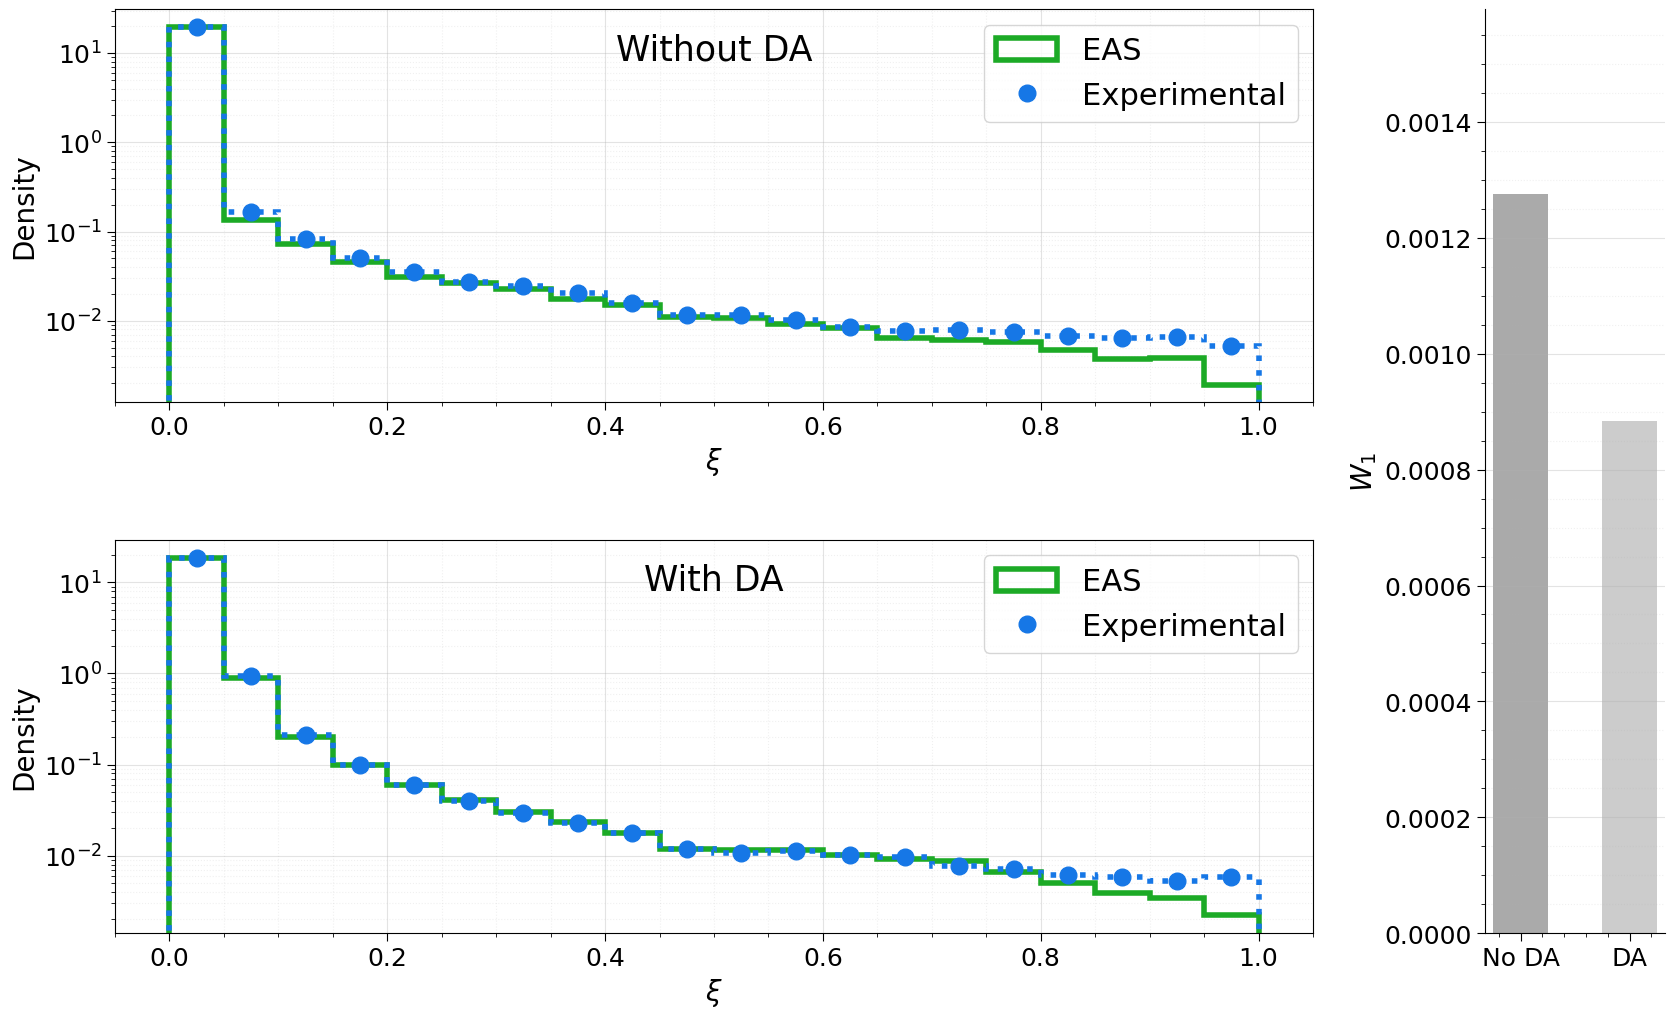

In [50]:
def _plot_panel(ax, mu, nu, exp, title, w_dist):
    print(len(mu), len(exp), len(nu))
    ax.hist(mu,  **HIST_KW, color="#1CAA26", lw=4,       label=f"EAS")
    kwargs = HIST_KW.copy()
    kwargs['ls'] = '--'
    ax.hist(exp, **kwargs, color="#1677E6", lw=4,       label=f"Experimental")

    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel("Density")
    ax.set_title(f"{title}", y=0.85, fontsize=25)
    ax.legend(fontsize=22)
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax.tick_params(which="major", length=6)
    ax.tick_params(which="minor", length=3)

def _plot_panel(ax, mu, nu, exp, title, w_dist):
    print(len(mu), len(exp), len(nu))
    ax.hist(mu, **HIST_KW, color="#1CAA26", lw=4, label="EAS")

    # Compute histogram manually to overlay markers on the line
    kwargs = HIST_KW.copy()
    kwargs['ls'] = ':'
    counts, bin_edges, _ = ax.hist(exp, **kwargs, color="#1677E6", lw=4)#, label="Experimental")
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, counts, marker="o", ms=12, color="#1677E6",
            linestyle="none", zorder=5, label="Experimental")

    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel("Density")
    ax.set_title(f"{title}", y=0.85, fontsize=25)
    ax.legend(fontsize=22)
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax.tick_params(which="major", length=6)
    ax.tick_params(which="minor", length=3)


def _plot_wasserstein(ax, w_noda, w_da):
    categories = ["No DA", "DA"]
    values     = [w_noda, w_da]
    colors     = ["#aaaaaa", "#cccccc"]

    bars = ax.bar(categories, values, color=colors, width=0.5, edgecolor="none")

    # for bar, val in zip(bars, values):
    #     ax.text(
    #         bar.get_x() + bar.get_width() / 2,
    #         bar.get_height() + max(values) * 0.02,
    #         f"{val:.4f}",
    #         ha="center", va="bottom", fontsize=16,
    #     )

    #ax.set_title("Wasserstein $W_1$")
    ax.set_ylabel("$W_1$")
    ax.set_ylim(0, max(values) * 1.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35, axis="y")
    ax.grid(True, which="minor", alpha=0.18, linestyle=":", axis="y")
    ax.tick_params(which="major", length=6)
    ax.tick_params(which="minor", length=3)


with plt.rc_context(RC_PARAMS):
    fig = plt.figure(figsize=(20, 12))
    gs  = fig.add_gridspec(2, 2, width_ratios=[10, 1.5], hspace=0.35, wspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[:, 1])   # spans both rows

    _plot_panel(ax1, mu_noda, nu_noda, exp_noda, "Without DA", w_noda)
    _plot_panel(ax2, mu_da,   nu_da,   exp_da,   "With DA",    w_da)
    _plot_wasserstein(ax3, w_noda, w_da)

    fig.savefig(f"prefilter_preds_distr_DAvsNoDA_reco_cuts_theta{THETA_CUTS}_{Path(DA_MODEL_NAME).stem}.png",
                bbox_inches="tight")
    plt.show()

'da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0'

Saved: /home/albert/Baikal2025/experiments/numu/../test_exp_reco_mc_reco/da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss/figures_test_mcexpreco/preds_distr_mcexp_reco_cuts_theta(0, 180).png


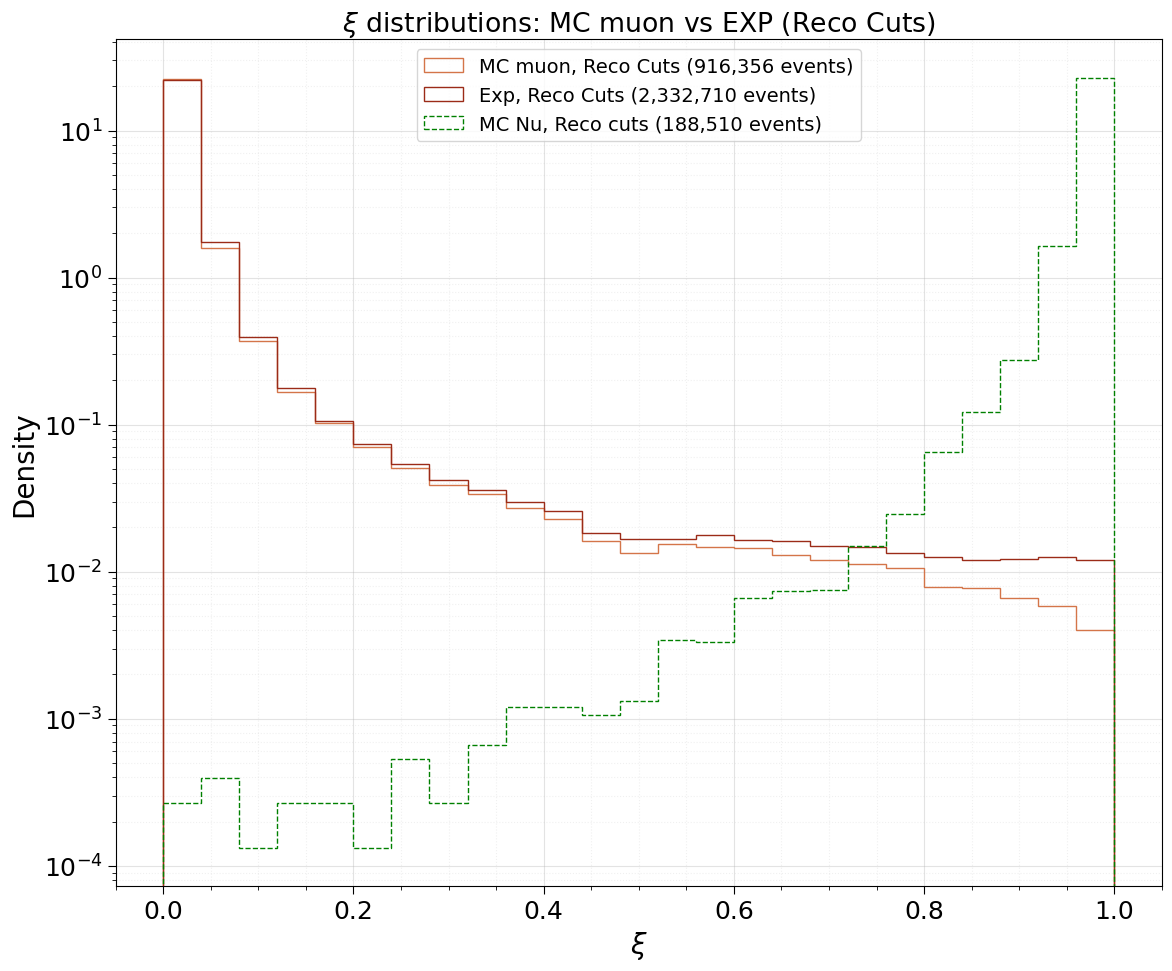

In [ ]:
THETA_CUTS = (0, 180)

mask_exp, _ = get_mask(df_exp_da, theta_cuts=THETA_CUTS)
mask_mc, _ = get_mask(df_mc_da, theta_cuts=THETA_CUTS)
# Score distribution: MC muons vs MC neutrinos vs Exp
mu = df_mc_da[(df_mc_da["particle_type"].str.startswith("muatm")) & mask_mc]["score"]
nu = df_mc_da[(df_mc_da["particle_type"].str.startswith("nu")) & mask_mc]["score"]
exp_reco = df_exp_da["score"][mask_exp]

# ── Plot ──
with plt.rc_context(RC_PARAMS):
    fig, ax = plt.subplots(figsize=(12, 10))
    B = 25
    ax.hist(mu, bins=B, range=(0,1), histtype='step', color="#D47549", log=True, density=True, label=f"MC muon, Reco Cuts ({len(mu):,} events)")
    ax.hist(exp_reco, bins=B, range=(0,1), histtype='step', color="#9B2B18", log=True, density=True, label=f"Exp, Reco Cuts ({len(exp_reco):,} events)")
    ax.hist(nu, bins=B, range=(0,1), histtype='step', ls='--', color='green', log=True, density=True, label=f"MC Nu, Reco cuts ({len(nu):,} events)")

    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel("Density") 
    ax.legend()
    ax.set_title(r"$\xi$ distributions: MC muon vs EXP (Reco Cuts)")
    
    ax.minorticks_on()
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax.tick_params(which="major", length=6)
    ax.tick_params(which="minor", length=3)

    plt.tight_layout()
    save_figure(fig, f"preds_distr_mcexp_reco_cuts_theta{THETA_CUTS}.png")
    plt.show()